# QSVT Resource Proxy Limits

QSVT resource reports are useful polynomial summaries, but they are not end-to-end runtime estimates. This notebook shows how degree and signal-call proxies should be read alongside omitted costs such as block encoding, state preparation, and measurement.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np

from qsvt.algorithms import spectral_thresholding_workflow
from qsvt.design import design_sign_polynomial
from qsvt.resources import qsvt_resource_report

## Degree Is Only One Part Of The Cost

The resource helper can count polynomial degree and signal-call proxies. It cannot know how an application prepares input states or implements a block encoding.

In [2]:
degrees = [5, 9, 13, 17]
reports = []
for degree in degrees:
    coeffs = design_sign_polynomial(gamma=0.25, degree=degree, num_points=401)
    reports.append(
        qsvt_resource_report(coeffs, matrix_dimension=16, attempt_synthesis=False)
    )

for report in reports:
    print(
        "Degree [polynomial degree]=",
        report["resources"]["degree"],
        ", Signal_calls [operator calls]=",
        report["resources"]["signal_operator_calls"],
        ", Encoding_qubits [qubits]=",
        report["resources"]["encoding_qubits"],
    )

Degree [polynomial degree]= 5 , Signal_calls [operator calls]= 5 , Encoding_qubits [qubits]= 4
Degree [polynomial degree]= 9 , Signal_calls [operator calls]= 9 , Encoding_qubits [qubits]= 4
Degree [polynomial degree]= 13 , Signal_calls [operator calls]= 13 , Encoding_qubits [qubits]= 4
Degree [polynomial degree]= 17 , Signal_calls [operator calls]= 17 , Encoding_qubits [qubits]= 4


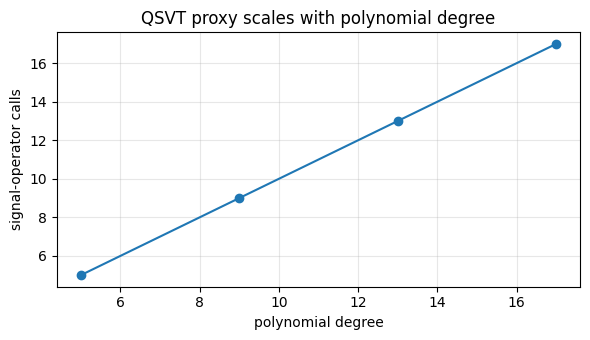

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(degrees, [r["resources"]["signal_operator_calls"] for r in reports], marker="o")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("signal-operator calls")
ax.set_title("QSVT proxy scales with polynomial degree")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Thresholding Example

Spectral thresholding exposes a common tradeoff: sharper interval edges need higher degree, and leakage outside the interval should be reported alongside rank or retained-weight proxies.

In [4]:
matrix = np.diag([-0.9, -0.2, 0.15, 0.55, 0.9])
state = np.array([0.1, 0.7, 0.5, 0.1, 0.2])

threshold = spectral_thresholding_workflow(
    matrix,
    lower=-0.3,
    upper=0.3,
    degree=32,
    sharpness=18.0,
    state=state,
    num_points=501,
)

print("Exact rank [states]:", threshold.exact_rank)
print("Rank proxy [states]:", round(float(threshold.polynomial_rank_proxy), 3))
print("Leakage:", round(threshold.leakage_outside_interval, 3))
print("State weight error:", round(threshold.state_weight_error, 3))

Exact rank [states]: 2
Rank proxy [states]: 1.955
Leakage: 0.017
State weight error: 0.008


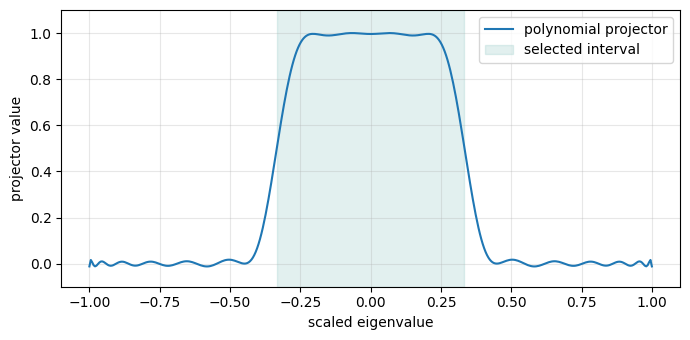

In [5]:
xs = np.linspace(-1.0, 1.0, 400)
vals = np.polynomial.polynomial.polyval(xs, threshold.coeffs)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(xs, vals, label="polynomial projector")
ax.axvspan(
    threshold.scaled_lower,
    threshold.scaled_upper,
    color="#72b7b2",
    alpha=0.2,
    label="selected interval",
)
ax.set_xlabel("scaled eigenvalue")
ax.set_ylabel("projector value")
ax.set_ylim(-0.1, 1.1)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Reading The Result

A small signal-call proxy says the polynomial sequence is compact. It does not say that the block encoding, input state, measurement strategy, or classical output extraction are cheap. Those assumptions must be specified separately for any end-to-end claim.